# Day 9: Classification Models in Machine Learning
## Logistic Regression, Confusion Matrix, KNN, and Hyperparameter Tuning

This notebook introduces classification for students learning machine learning for the first time.

Classification predicts categories such as pass/fail, spam/not spam, disease/no disease, or pedestrian/vehicle/building.

Today we cover:
- Sigmoid function intuition
- Logistic Regression
- Prediction probabilities
- Confusion matrix
- Precision, recall, F1-score
- K-Nearest Neighbours
- Hyperparameter tuning for KNN

---
# Setup

If students get an import error in Colab, run:

```python
!pip install matplotlib seaborn scikit-learn
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

print("Day 9 Classification Environment Initialized.")
np.random.seed(42)

Day 9 Classification Environment Initialized.


---
# 1. The Sigmoid Function Intuition

Logistic Regression first creates a linear output:

```text
z = wx + b
```

But classification needs a probability between 0 and 1.

The sigmoid function converts any real number into a probability:

```text
sigmoid(z) = 1 / (1 + e^-z)
```

Important points:
- Negative `z` values move toward probability 0
- `z = 0` gives probability 0.5
- Positive `z` values move toward probability 1

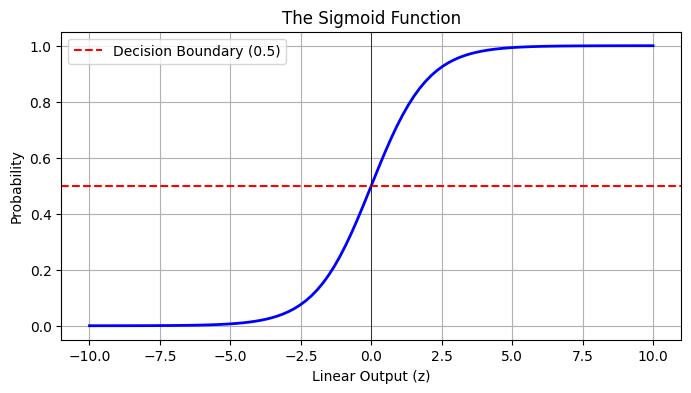

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
probabilities = sigmoid(z)

plt.figure(figsize=(8, 4))
plt.plot(z, probabilities, color="blue", linewidth=2)
plt.axhline(0.5, color="red", linestyle="--", label="Decision Boundary (0.5)")
plt.axvline(0, color="black", linewidth=0.5)
plt.title("The Sigmoid Function")
plt.xlabel("Linear Output (z)")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

## Extra: Sigmoid Values Table

This helps students connect the graph to actual probability values.

In [4]:
z_values = np.array([-5, -2, -1, 0, 1, 2, 5])
sigmoid_values = sigmoid(z_values)

for z_val, prob in zip(z_values, sigmoid_values):
    print(f"z = {z_val:>2}  ->  probability = {prob:.4f}")

z = -5  ->  probability = 0.0067
z = -2  ->  probability = 0.1192
z = -1  ->  probability = 0.2689
z =  0  ->  probability = 0.5000
z =  1  ->  probability = 0.7311
z =  2  ->  probability = 0.8808
z =  5  ->  probability = 0.9933


---
# 2. Logistic Regression: Multimodal Autograder

We will build a classifier to predict whether a student passes the Spring 2026 AI course.

Features:
- Vision processing assignment score
- Text processing assignment score

Label:
- `0` = Fail
- `1` = Pass

In [5]:
vision_scores = np.random.normal(70, 15, 123)
text_scores = np.random.normal(75, 12, 123)

labels = (((vision_scores + text_scores) / 2) + np.random.normal(0, 5, 123) > 70).astype(int)

X = np.column_stack((vision_scores, text_scores))
y = labels

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("First 5 feature rows:")
print(X[:5])
print("First 5 labels:")
print(y[:5])

Feature matrix shape: (123, 2)
Label vector shape: (123,)
First 5 feature rows:
[[ 77.4507123   58.17778725]
 [ 67.92603548  82.04228513]
 [ 79.71532807 101.28546751]
 [ 92.84544785  63.1135641 ]
 [ 66.48769938  68.20442724]]
First 5 labels:
[0 1 1 1 0]


## Visualizing the Classification Dataset

Each point represents one student.

The color shows whether the student passed or failed.

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.75)
plt.title("Student Pass/Fail Dataset")
plt.xlabel("Vision Score")
plt.ylabel("Text Score")
plt.colorbar(label="Class: 0 = Fail, 1 = Pass")
plt.grid(True)
plt.show()

---
# Train-Test Split

The model learns from training data and is evaluated on unseen test data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training label shape:", y_train.shape)
print("Testing label shape:", y_test.shape)

Training feature shape: (98, 2)
Testing feature shape: (25, 2)
Training label shape: (98,)
Testing label shape: (25,)


---
# Training Logistic Regression

Scikit-learn models usually follow this pattern:

```python
model = ModelName()
model.fit(X_train, y_train)
model.predict(X_test)
```

In [7]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

print("Model Training Complete.")
print(f"Learned Weights: {log_model.coef_}")
print(f"Learned Bias: {log_model.intercept_}")

Model Training Complete.
Learned Weights: [[0.27148002 0.23514941]]
Learned Bias: [-35.31659767]


## Extra: Prediction Probabilities

`predict()` gives class labels.

`predict_proba()` gives probabilities for each class.

In [8]:
probabilities_test = log_model.predict_proba(X_test)

print("First 5 prediction probabilities:")
print(probabilities_test[:5])

print("\nFirst 5 predicted classes:")
print(log_model.predict(X_test[:5]))

First 5 prediction probabilities:
[[0.21181169 0.78818831]
 [0.90892465 0.09107535]
 [0.04237096 0.95762904]
 [0.00222597 0.99777403]
 [0.77351829 0.22648171]]

First 5 predicted classes:
[1 0 1 1 0]


---
# 3. Evaluating the Logistic Classifier

Accuracy alone is not enough.

A confusion matrix shows:

- True Positives
- True Negatives
- False Positives
- False Negatives

For student prediction:
- False Positive: Model predicts Pass, actual is Fail
- False Negative: Model predicts Fail, actual is Pass

In [ ]:
y_pred_log = log_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="g",
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"]
)
plt.title("Autograder Confusion Matrix")
plt.show()

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_log, target_names=["Fail", "Pass"]))

## Precision, Recall, and F1

Precision asks: of all predicted positives, how many were actually positive?

Recall asks: of all actual positives, how many did the model find?

F1-score balances precision and recall.

## Extra: Logistic Regression Decision Boundary

A decision boundary shows where the model changes from predicting class 0 to class 1.

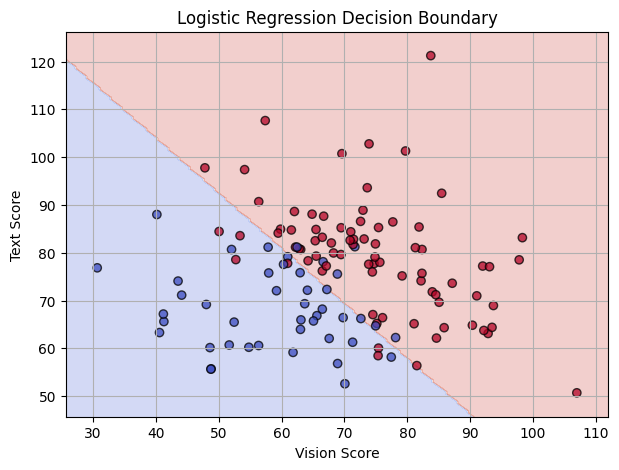

In [12]:
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_predictions = log_model.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, grid_predictions, alpha=0.25, cmap="coolwarm")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.75)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Vision Score")
plt.ylabel("Text Score")
plt.grid(True)
plt.show()

---
# 4. K-Nearest Neighbours: Spatial Classification

KNN classifies a new point by looking at nearby training examples.

If `K = 5`, the model checks the 5 nearest neighbours and chooses the majority class.

Here we classify 3D streetscape objects:

- `0` = Pedestrian
- `1` = Vehicle
- `2` = Building

In [9]:
X_spatial = np.random.rand(300, 3) * 100

y_spatial = []

for coords in X_spatial:
    if coords[2] > 60:
        y_spatial.append(2)
    elif coords[0] < 50:
        y_spatial.append(0)
    else:
        y_spatial.append(1)

y_spatial = np.array(y_spatial)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_spatial, y_spatial, test_size=0.2, random_state=42
)

knn_model = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_model.fit(X_train_s, y_train_s)

accuracy_knn = knn_model.score(X_test_s, y_test_s)

print(f"KNN Spatial Classification Accuracy (K=5): {accuracy_knn * 100:.2f}%")

KNN Spatial Classification Accuracy (K=5): 88.33%


## Visualizing 3D Spatial Classes in 2D

We plot X and Z because the class rules depend strongly on these coordinates.

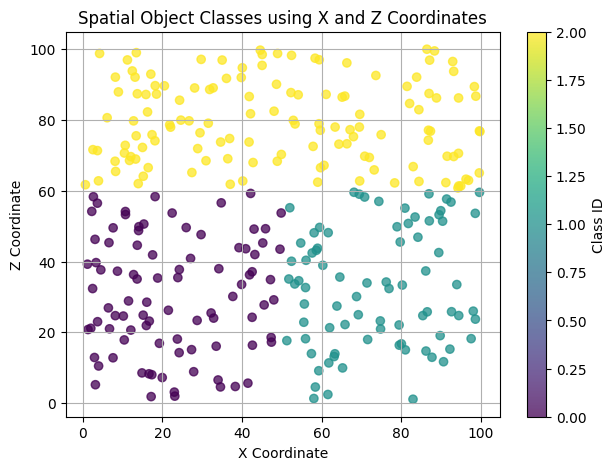

{0: 'Pedestrian', 1: 'Vehicle', 2: 'Building'}


In [10]:
class_names = {0: "Pedestrian", 1: "Vehicle", 2: "Building"}

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_spatial[:, 0], X_spatial[:, 2], c=y_spatial, cmap="viridis", alpha=0.75)
plt.title("Spatial Object Classes using X and Z Coordinates")
plt.xlabel("X Coordinate")
plt.ylabel("Z Coordinate")
plt.colorbar(scatter, label="Class ID")
plt.grid(True)
plt.show()

print(class_names)

## Extra: KNN Prediction for a New Object

In [11]:
new_object = np.array([[30, 40, 20]])

predicted_class = knn_model.predict(new_object)[0]

print("New object coordinates:", new_object[0])
print("Predicted class ID:", predicted_class)
print("Predicted class name:", class_names[predicted_class])

New object coordinates: [30 40 20]
Predicted class ID: 0
Predicted class name: Pedestrian


---
# 5. Hyperparameter Tuning: Finding the Best K

KNN has an important hyperparameter:

```python
n_neighbors
```

If K is too small, the model may be sensitive to noise.

If K is too large, the model may become too smooth.

So we test multiple K values and compare error rates.

In [ ]:
error_rates = []
k_values = range(1, 40, 2)

for i in k_values:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_s, y_train_s)
    pred_i = knn.predict(X_test_s)
    error_rates.append(np.mean(pred_i != y_test_s))

plt.figure(figsize=(8, 4))
plt.plot(
    list(k_values),
    error_rates,
    color="purple",
    linestyle="dashed",
    marker="o",
    markerfacecolor="red",
    markersize=8
)
plt.title("Error Rate vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()

best_k = list(k_values)[np.argmin(error_rates)]
print(f"The optimal K value with the lowest error rate is: K={best_k}")

## Extra: Accuracy vs K

In [ ]:
accuracy_values = [1 - error for error in error_rates]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), accuracy_values, marker="o")
plt.title("Accuracy vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

print(f"Best K: {best_k}")
print(f"Best Accuracy: {max(accuracy_values) * 100:.2f}%")

---
# Logistic Regression vs KNN Summary

| Model | Main Idea | Strength | Limitation |
|---|---|---|---|
| Logistic Regression | Learns a mathematical boundary | Simple and interpretable | Works best with linear separation |
| KNN | Looks at nearest examples | Intuitive and flexible | Can be slow for large datasets |

In [ ]:
log_accuracy = accuracy_score(y_test, y_pred_log)
knn_accuracy = accuracy_knn

print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

models = ["Logistic Regression", "KNN"]
accuracies = [log_accuracy, knn_accuracy]

plt.figure(figsize=(7, 4))
plt.bar(models, accuracies)
plt.title("Classification Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

---
# Day 9 Hands-On Coding Test

The following problems are for students to solve independently.

No solutions are provided in this test section.

# Test 1: Easy
## Sigmoid and Thresholding

You are given raw model outputs:

```python
z_values = np.array([-3, -1, 0, 2, 4])
```

Write Python code to:

1. Define a sigmoid function
2. Convert `z_values` into probabilities
3. Print probabilities rounded to 4 decimals
4. Convert probabilities into class predictions using threshold `0.5`
5. Print the predicted classes

In [ ]:
# Test 1 Student Code

import numpy as np

z_values = np.array([-3, -1, 0, 2, 4])

# Write your solution here

---
# Test 2: Medium
## Logistic Regression Classifier

Create the following dataset:

```python
X = np.array([
    [35, 40],
    [50, 55],
    [60, 65],
    [70, 75],
    [80, 85],
    [90, 95],
    [45, 50],
    [85, 80]
])

y = np.array([0, 0, 0, 1, 1, 1, 0, 1])
```

Write Python code to:

1. Split the dataset using `test_size=0.25` and `random_state=42`
2. Train a Logistic Regression model
3. Predict on the test set
4. Print accuracy
5. Print the confusion matrix

In [ ]:
# Test 2 Student Code

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

X = np.array([
    [35, 40],
    [50, 55],
    [60, 65],
    [70, 75],
    [80, 85],
    [90, 95],
    [45, 50],
    [85, 80]
])

y = np.array([0, 0, 0, 1, 1, 1, 0, 1])

# Write your solution here

---
# Test 3: Hard
## KNN Hyperparameter Tuning

Create a synthetic dataset:

```python
np.random.seed(10)
X_knn = np.random.rand(100, 2) * 100
y_knn = (X_knn[:, 0] + X_knn[:, 1] > 100).astype(int)
```

Write Python code to:

1. Split the dataset using `test_size=0.2` and `random_state=42`
2. Test odd K values from 1 to 19
3. Train a KNN model for each K
4. Calculate the error rate for each K
5. Plot error rate vs K
6. Print the best K value
7. Train a final KNN model using the best K
8. Print the final test accuracy

In [ ]:
# Test 3 Student Code

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

np.random.seed(10)
X_knn = np.random.rand(100, 2) * 100
y_knn = (X_knn[:, 0] + X_knn[:, 1] > 100).astype(int)

# Write your solution here

---
# End of Day 9 Notebook

By the end of this notebook, students should understand:

- Classification vs regression
- Sigmoid probabilities
- Logistic Regression
- Confusion matrix
- Precision, recall, and F1-score
- KNN nearest-neighbour logic
- KNN hyperparameter tuning
- How to compare classification models